# 01 — Análisis Operacional — LockBit Panel

Análisis de datos estructurados **sin LLM**: jerarquía de operadores, ciclo de vida  
de víctimas, evolución de builds y funnel de pagos.

Requiere haber ejecutado primero `00_extract_and_explore.ipynb`.

## 0. Setup

In [1]:
# "json" es un módulo estándar de Python para leer y escribir datos en formato JSON.
# JSON es el formato más común para guardar datos estructurados en texto (como listas y diccionarios).
# Lo necesitamos aquí porque el campo 'permissions' de los usuarios está guardado como JSON.
import json

# "pandas" es la librería de análisis de datos. Con ella trabajamos tablas (DataFrames).
import pandas as pd

# "numpy" es la librería de cálculo numérico. Aquí la usamos principalmente
# para manejar valores especiales como NaN (Not a Number, es decir, "dato no disponible").
import numpy as np

# "matplotlib.pyplot" es la librería de gráficas. La abreviamos como "plt".
import matplotlib.pyplot as plt

# "matplotlib.patches" nos permite añadir formas geométricas a los gráficos,
# por ejemplo rectángulos de colores para leyendas personalizadas.
import matplotlib.patches as mpatches

# "Path" para manejar rutas de archivos de forma portable entre sistemas operativos.
from pathlib import Path

# Definimos la carpeta donde están los archivos parquet generados por el notebook 00.
PROCESSED = Path('../data_Vruto/LockBit')

# Verificamos que todos los archivos necesarios existen antes de continuar.
# Si falta alguno, el usuario verá un mensaje claro explicando qué tiene que hacer.
for t in ['users', 'clients', 'chats', 'builds', 'invites']:
    assert (PROCESSED / f'{t}.parquet').exists(), f'Falta {t}.parquet — ejecuta notebook 00'

# Cargamos cada tabla desde su archivo parquet.
# pd.read_parquet() es muy rápido: lee el archivo binario directamente como DataFrame.
users   = pd.read_parquet(PROCESSED / 'users.parquet')
clients = pd.read_parquet(PROCESSED / 'clients.parquet')
chats   = pd.read_parquet(PROCESSED / 'chats.parquet')
builds  = pd.read_parquet(PROCESSED / 'builds.parquet')
invites = pd.read_parquet(PROCESSED / 'invites.parquet')

print('Datos cargados OK')

Datos cargados OK


## 1. Jerarquía de operadores

El campo `permissions` es un JSON array con los módulos habilitados para cada afiliado.  
El campo `level` indica jerarquía: 4 = admin, 1 = afiliado estándar.

In [2]:
# Función auxiliar para convertir el campo 'permissions' de JSON a lista Python.
# El campo está guardado como texto (ej: '["build","chat","files"]'),
# y necesitamos convertirlo a una lista real para poder analizarlo.
def parse_permissions(perm_str):
    try:
        # json.loads() convierte una cadena de texto JSON a objetos Python
        # Si perm_str está vacío (None o ''), devolvemos una lista vacía
        return json.loads(perm_str) if perm_str else []
    except Exception:
        # Si el JSON es inválido, devolvemos lista vacía en lugar de dar error
        return []

# Aplicamos la función a cada fila de la columna 'permissions'.
# .apply() toma una función y la ejecuta para cada valor de la columna,
# devolviendo una nueva columna con los resultados.
users['perms_list'] = users['permissions'].apply(parse_permissions)

# Contamos cuántos permisos tiene cada usuario (cuántos módulos puede usar).
# .apply(len) aplica la función len() (longitud) a cada lista de permisos.
users['n_perms'] = users['perms_list'].apply(len)

# Mapa nivel → etiqueta: traducimos los códigos numéricos de nivel a nombres descriptivos.
# Esto hace los resultados más fáciles de leer e interpretar.
level_map = {4: 'Admin', 3: 'Manager', 2: 'Senior', 1: 'Afiliado'}

# .map(level_map) sustituye cada valor numérico por su texto correspondiente.
# .fillna('Desconocido') rellena con 'Desconocido' los valores que no están en el mapa.
users['role'] = users['level'].map(level_map).fillna('Desconocido')

# Mostramos la distribución de roles en la organización criminal
print('=== JERARQUÍA ===')
# groupby('role') agrupa los usuarios por rol
# ['login'].count() cuenta cuántos usuarios hay en cada grupo
print(users.groupby('role')['login'].count().to_string())
print()

# Mostramos los operadores con más permisos: suelen ser los más confiables o activos.
# sort_values('n_perms', ascending=False) ordena de mayor a menor número de permisos.
print('Operadores con más permisos:')
print(users[['login','role','tag','n_perms','last_online_dt']].sort_values('n_perms', ascending=False).head(10).to_string())

=== JERARQUÍA ===
role
Admin        1
Afiliado    74

Operadores con más permisos:
              login      role       tag  n_perms            last_online_dt
0             admin     Admin                 10 2025-04-29 12:46:02+00:00
1         matrix777  Afiliado                 10 2025-04-29 11:29:42+00:00
2             fedor  Afiliado    newbie       10 2024-12-19 00:10:02+00:00
3        KeaynBaker  Afiliado    newbie       10 2024-12-19 01:20:25+00:00
4              five  Afiliado    newbie       10 2024-12-20 14:57:05+00:00
5        OranBarnes  Afiliado    newbie       10 2025-01-31 13:44:07+00:00
6      BroganAlbert  Afiliado    newbie       10 2024-12-19 00:33:22+00:00
7   FezaanBlanchard  Afiliado    newbie       10 2024-12-19 00:34:39+00:00
8  ArdalBlankenship  Afiliado    newbie       10 2025-02-14 20:25:14+00:00
9             Brown  Afiliado  verified       10 2025-04-03 13:40:39+00:00


In [3]:
# Calculamos estadísticas de actividad por operador: cuántos builds generó,
# cuántas víctimas tuvo asignadas y cuántos mensajes de chat envió.
# Esto nos permite identificar quiénes eran los operadores más activos.

# Contamos builds por operador (userid es el ID del operador que compiló el build)
op_builds  = builds.groupby('userid').size().rename('n_builds')

# Contamos víctimas por operador (advid = advertiser ID, identifica al operador de cada víctima)
op_victims = clients.groupby('advid').size().rename('n_victims')

# Contamos mensajes de chat enviados por operadores (flag==1 filtra solo los mensajes del operador)
op_chats   = chats[chats.flag == 1].groupby('advid').size().rename('n_chat_msgs')

# Construimos una tabla combinada con los datos de cada operador.
# La construimos paso a paso:
#   users.set_index('id') → ponemos el ID del usuario como índice de la tabla
#   .join(op_builds, how='left') → añadimos la columna n_builds (left join: conservamos todos los usuarios)
#   .join(op_victims, how='left') → añadimos la columna n_victims
#   .join(op_chats, how='left') → añadimos la columna n_chat_msgs
#   .fillna(0) → los operadores sin builds/víctimas/chats tienen NaN, lo cambiamos por 0
#   .sort_values('n_victims', ascending=False) → ordenamos por número de víctimas (de más a menos)
op_stats = (users.set_index('id')
            .join(op_builds, how='left')
            .join(op_victims, how='left')
            .join(op_chats, how='left')
            .fillna(0)
            .sort_values('n_victims', ascending=False))

# Mostramos una tabla con los 20 operadores más activos
print('Top 20 operadores por víctimas asignadas:')
# display() muestra el DataFrame de forma visual en Jupyter (con colores y alineación)
display(op_stats[['login','role','tag','n_victims','n_builds','n_chat_msgs','last_online_dt']].head(20))

Top 20 operadores por víctimas asignadas:


,login,role,tag,n_victims,n_builds,n_chat_msgs,last_online_dt
id,,,,,,,
25,Christopher,Afiliado,verified,44.0,70.0,1073.0,2025-04-29 06:18:30+00:00
18,jhon0722,Afiliado,newbie,42.0,16.0,9.0,2025-04-21 05:15:58+00:00
12,PiotrBond,Afiliado,newbie,19.0,53.0,134.0,2025-04-29 11:09:36+00:00
43,JamesCraig,Afiliado,verified,17.0,170.0,152.0,2025-04-29 05:42:46+00:00
70,Swan,Afiliado,verified,17.0,147.0,142.0,2025-04-29 13:23:24+00:00
65,Iofikdis,Afiliado,newbie,12.0,79.0,248.0,2025-04-29 11:17:03+00:00
28,umarbishop47,Afiliado,newbie,10.0,74.0,71.0,2025-04-29 11:49:13+00:00
15,Anon666,Afiliado,newbie,7.0,32.0,26.0,2025-03-28 21:51:31+00:00
21,smelly,Afiliado,newbie,7.0,15.0,2.0,2024-12-23 16:53:57+00:00


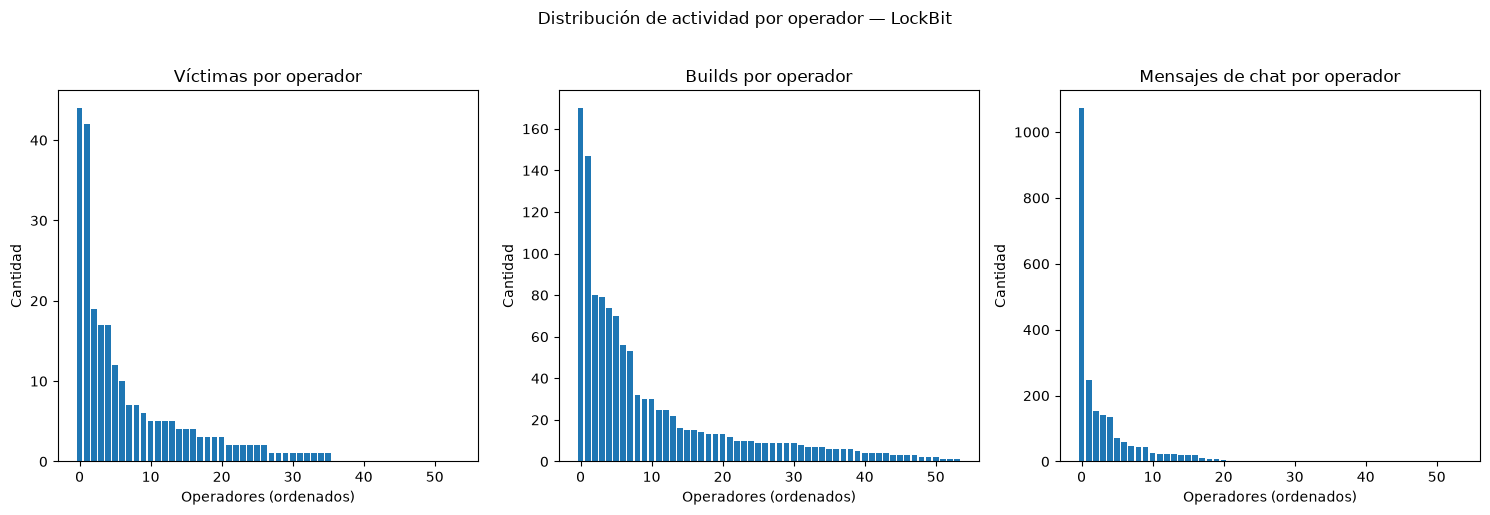

In [4]:
# Visualizamos cómo se distribuye la actividad entre los operadores.
# Esto nos ayuda a ver si unos pocos operadores concentran la mayoría del trabajo
# (distribución de "cola larga" típica en organizaciones criminales).

# Filtramos solo los operadores que tuvieron alguna actividad (al menos 1 víctima o 1 build).
# .copy() crea una copia independiente para evitar advertencias de pandas al modificarla.
active = op_stats[(op_stats.n_victims > 0) | (op_stats.n_builds > 0)].copy()

# Creamos tres gráficas de barras juntas (1 fila, 3 columnas).
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# zip() combina tres listas en paralelo: (eje, columna, título) para cada gráfica.
# Esto evita escribir el mismo código tres veces con pequeñas variaciones.
for ax, col, title in zip(axes,
                          ['n_victims', 'n_builds', 'n_chat_msgs'],
                          ['Víctimas por operador', 'Builds por operador', 'Mensajes de chat por operador']):
    # Ordenamos los valores de mayor a menor para visualizar la concentración de actividad
    data = active[col].sort_values(ascending=False)

    # range(len(data)) crea el eje X con posiciones numéricas (0, 1, 2, ...)
    # ya que no podemos usar los nombres directamente en este tipo de gráfica
    ax.bar(range(len(data)), data.values)
    ax.set_title(title)
    ax.set_xlabel('Operadores (ordenados)')
    ax.set_ylabel('Cantidad')

# Título general que aparece encima de las tres gráficas.
# y=1.02 lo sube ligeramente para que no se solape con las gráficas.
plt.suptitle('Distribución de actividad por operador — LockBit', y=1.02)

# Ajustamos el espaciado para que las tres gráficas no se solapen entre sí
plt.tight_layout()
plt.show()

## 2. Ciclo de vida de víctimas

Seguimiento desde el primer acceso al panel hasta el pago (si se produce).

In [5]:
# Analizamos el ciclo de vida de cada víctima en el panel de LockBit:
# cuánto tiempo estuvo activa desde que aparecieron en el sistema hasta el último contacto.

# Calculamos cuántos días estuvo activa cada víctima.
# date_last - date_first → resta las dos fechas y devuelve un timedelta (duración)
# .dt.total_seconds() → convierte la duración a segundos totales
# / 86400 → dividimos entre 86400 (60*60*24) para convertir segundos a días
clients['days_active'] = (clients['date_last'] - clients['date_first']).dt.total_seconds() / 86400

# Eliminamos las filas donde no podemos calcular los días activos (fechas faltantes)
clients_valid = clients.dropna(subset=['days_active'])

# Estadísticas del ciclo de vida
print('=== CICLO DE VIDA DE VÍCTIMAS ===')
# La mediana es el valor del "centro" cuando ordenamos todos los valores de menor a mayor.
# Usamos la mediana en lugar de la media porque es más resistente a valores extremos.
print(f'Tiempo activo mediana : {clients_valid.days_active.median():.1f} días')
print(f'Tiempo activo máx     : {clients_valid.days_active.max():.0f} días')

# 'views' cuenta cuántas veces la víctima entró a su página de negociación
print(f'Vistas al panel (median): {clients.views.median():.0f}')
print()

# Construimos el "funnel de conversión": cuántas víctimas pasan por cada etapa.
# Este concepto viene del marketing: de todos los que entran, cuántos acaban pagando.
total = len(clients)

# Víctimas que tuvieron al menos un mensaje de chat (iniciaron negociación)
# .isin() devuelve True si el valor de clients.id está en la columna chats.clientid
with_chat  = clients.id.isin(chats.clientid).sum()

# Víctimas que pagaron el rescate (paid_commission indica pago de la comisión del afiliado)
paid       = (clients.paid_commission == 1).sum()

# Víctimas que recibieron sus archivos desencriptados (proceso completado)
decrypted  = (clients.decrypt_done > 0).sum()

# Imprimimos el funnel mostrando el número y el porcentaje en cada etapa
print('=== FUNNEL DE CONVERSIÓN ===')
print(f'  1. Víctimas en panel       : {total:>4}  (100%)')
# {with_chat/total*100:.1f}% calcula el porcentaje con 1 decimal
print(f'  2. Con chat iniciado       : {with_chat:>4}  ({with_chat/total*100:.1f}%)')
print(f'  3. Pagaron comisión        : {paid:>4}  ({paid/total*100:.1f}%)')
print(f'  4. Descifrado completado   : {decrypted:>4}  ({decrypted/total*100:.1f}%)')

=== CICLO DE VIDA DE VÍCTIMAS ===
Tiempo activo mediana : 0.0 días
Tiempo activo máx     : 123 días
Vistas al panel (median): 11

=== FUNNEL DE CONVERSIÓN ===
  1. Víctimas en panel       :  246  (100%)
  2. Con chat iniciado       :  208  (84.6%)
  3. Pagaron comisión        :    7  (2.8%)
  4. Descifrado completado   :    0  (0.0%)


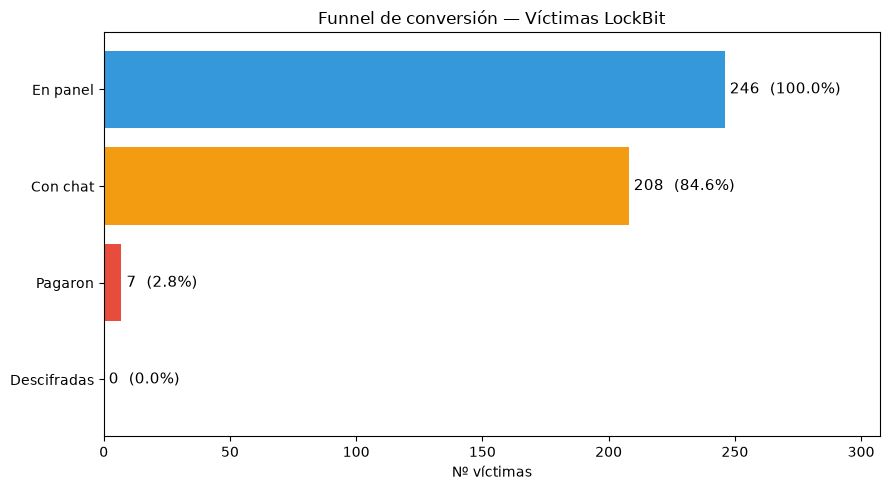

In [6]:
# Visualizamos el funnel de conversión como un gráfico de barras horizontales.
# Las barras horizontales son mejores que las verticales cuando las etiquetas son largas.

# Definimos las etapas del funnel y sus valores, en orden de más a menos víctimas
stages = ['En panel', 'Con chat', 'Pagaron', 'Descifradas']
counts = [total, with_chat, paid, decrypted]

# Colores: azul para la etapa inicial, naranja para las intermedias, rojo para pagaron,
# verde para descifradas (aunque está en 0, el color verde indica el resultado deseado)
colors = ['#3498db', '#f39c12', '#e74c3c', '#2ecc71']

# Creamos la figura
fig, ax = plt.subplots(figsize=(9, 5))

# [::-1] invierte el orden de la lista para que el funnel vaya de arriba (mayor) a abajo (menor)
# ax.barh() dibuja barras horizontales (h = horizontal)
bars = ax.barh(stages[::-1], counts[::-1], color=colors[::-1])

# Añadimos etiquetas de texto al final de cada barra mostrando el número y el porcentaje
for bar, n in zip(bars, counts[::-1]):
    pct = n / total * 100
    # bar.get_width() → longitud de la barra (= el valor numérico)
    # bar.get_y() + bar.get_height()/2 → posición vertical centrada en la barra
    # va='center' → alinea el texto verticalmente al centro de la barra
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{n}  ({pct:.1f}%)', va='center', fontsize=11)

# Ajustamos el límite del eje X para que haya espacio para las etiquetas de texto
ax.set_xlim(0, total * 1.25)
ax.set_title('Funnel de conversión — Víctimas LockBit')
ax.set_xlabel('Nº víctimas')
plt.tight_layout()
plt.show()

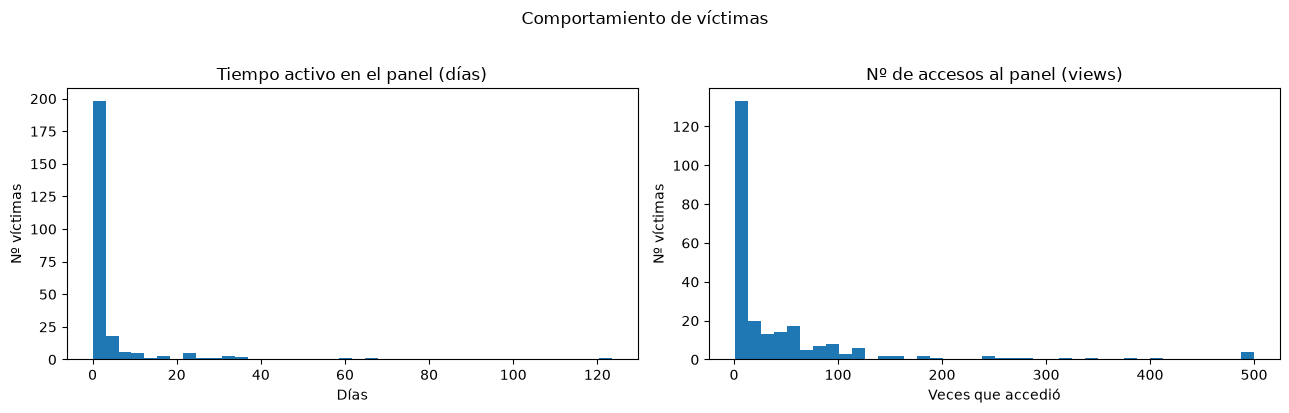

In [7]:
# Visualizamos la distribución del tiempo que las víctimas permanecieron activas
# y la distribución de cuántas veces accedieron al panel de negociación.

# Dos histogramas lado a lado para comparar ambas distribuciones
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histograma izquierdo: distribución de días activos ---
# .clip(upper=180) limita los valores al máximo de 180 días.
# Esto evita que unos pocos valores extremos aplasten el histograma y oculten el patrón principal.
# bins=40 divide el rango de datos en 40 barras (más barras = más detalle)
# edgecolor='none' quita el borde negro de cada barra para un aspecto más limpio
axes[0].hist(clients_valid.days_active.clip(upper=180), bins=40, edgecolor='none')
axes[0].set_title('Tiempo activo en el panel (días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Nº víctimas')

# --- Histograma derecho: distribución de vistas al panel ---
# .clip(upper=500) limita al máximo de 500 vistas para no deformar el gráfico
# 'views' cuenta cuántas veces cada víctima entró a ver su panel de negociación
axes[1].hist(clients.views.clip(upper=500), bins=40, edgecolor='none')
axes[1].set_title('Nº de accesos al panel (views)')
axes[1].set_xlabel('Veces que accedió')
axes[1].set_ylabel('Nº víctimas')

# Título general para los dos histogramas juntos
plt.suptitle('Comportamiento de víctimas', y=1.02)
plt.tight_layout()
plt.show()

## 3. Evolución de builds de malware

LockBit usa variantes identificadas por tipo (25, 30, 40, 46, 50).  
Cada build puede estar asociado a una víctima específica (`company_website`).

In [8]:
# Analizamos los builds de malware: los ejecutables de ransomware que los operadores
# generaban para cada campaña. Cada build es un ejecutable personalizado para una víctima.

# Filtramos los builds que tienen fecha válida para el análisis temporal
builds_valid = builds.dropna(subset=['date'])

# Diccionario para traducir los códigos numéricos de tipo a nombres de versión legibles.
# Estas versiones representan la evolución del malware LockBit a lo largo del tiempo.
type_names = {25: 'LB 2.5', 30: 'LB 3.0', 40: 'LB 4.0', 46: 'LB 4.6', 50: 'LB 5.0'}

# Estadísticas generales de los builds
print('=== BUILDS DE MALWARE ===')
print(f'Total builds: {len(builds)}')

# Cuántos operadores distintos compilaron al menos un build (no todos los usuarios lo hicieron)
print(f'Operadores que crearon builds: {builds.userid.nunique()}')
print()

# Mostramos cuántos builds hay de cada versión de LockBit.
# .sort_index() ordena por el código numérico del tipo (25, 30, 40, 46, 50)
# .items() devuelve pares (tipo, cantidad) para iterar con for
for t, cnt in builds.type.value_counts().sort_index().items():
    # type_names.get(t, "?") devuelve el nombre si existe, o "?" si no está en el diccionario
    print(f'  Tipo {t} ({type_names.get(t, "?")}): {cnt:4d} builds')

=== BUILDS DE MALWARE ===
Total builds: 1183
Operadores que crearon builds: 54

  Tipo 25 (LB 2.5):  297 builds
  Tipo 30 (LB 3.0):  504 builds
  Tipo 40 (LB 4.0):  143 builds
  Tipo 46 (LB 4.6):  151 builds
  Tipo 50 (LB 5.0):   88 builds


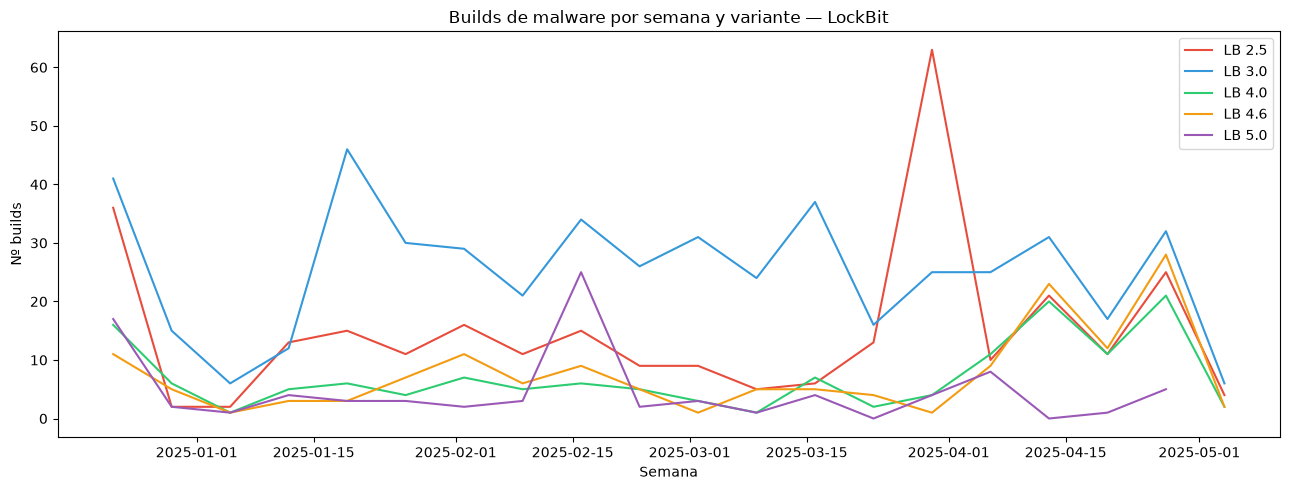

In [9]:
# Visualizamos la evolución temporal de compilaciones de malware, desglosando por versión.
# Esto muestra qué versiones de LockBit eran más populares en cada momento.

# Diccionario de colores: cada versión de LockBit tiene un color distinto en el gráfico
type_colors = {25: '#e74c3c', 30: '#3498db', 40: '#2ecc71', 46: '#f39c12', 50: '#9b59b6'}

# Creamos una figura con un único gráfico de líneas temporal
fig, ax = plt.subplots(figsize=(13, 5))

# Dibujamos una línea por cada versión de LockBit que aparezca en los datos.
# .unique() devuelve los valores únicos (sin repetir) de la columna 'type'
# sorted() los ordena numéricamente
for btype in sorted(builds_valid.type.unique()):
    # Filtramos solo los builds de este tipo específico
    sub = builds_valid[builds_valid.type == btype].set_index('date').resample('W').size()

    # ax.plot() dibuja una línea (a diferencia de ax.bar() que dibuja barras)
    # label= es el texto que aparecerá en la leyenda
    # color= asigna el color del diccionario (o gris '#95a5a6' si el tipo no está en él)
    # linewidth=1.5 controla el grosor de la línea
    ax.plot(sub.index, sub.values, label=type_names.get(btype, str(btype)),
            color=type_colors.get(btype, '#95a5a6'), linewidth=1.5)

ax.set_title('Builds de malware por semana y variante — LockBit')
ax.set_xlabel('Semana')
ax.set_ylabel('Nº builds')

# ax.legend() añade la leyenda que muestra qué color corresponde a cada versión
ax.legend()
plt.tight_layout()
plt.show()

## 4. Estructura de reclutamiento (invites)

In [10]:
# Analizamos la estructura de reclutamiento a través de los 'invites'.
# LockBit operaba como un RaaS (Ransomware as a Service): los criminales pagaban
# una cuota de entrada en criptomoneda para acceder al panel y usar el malware.

# Convertimos el campo 'amount' a número para poder calcular estadísticas.
# errors='coerce' convierte los valores que no son números a NaN (no disponible).
invites['amount_f'] = pd.to_numeric(invites['amount'], errors='coerce')

# Determinamos qué criptomoneda usó cada afiliado para pagar su cuota de entrada.
# .apply() con una función lambda aplica la lógica a cada fila del DataFrame.
# La lógica es: si tiene wallet BTC → 'BTC', si tiene wallet XMR → 'XMR', si no tiene → 'N/A'
# pd.notna() devuelve True si el valor NO es nulo/vacío
invites['crypto'] = invites.apply(
    lambda r: 'BTC' if pd.notna(r.btc_wallet) else ('XMR' if pd.notna(r.monero_wallet) else 'N/A'), axis=1
)

# Estadísticas del sistema de reclutamiento
print('=== INVITES DE AFILIACIÓN ===')
print(f'Total invites creados : {len(invites)}')
# status=50 = invite aceptada (el afiliado se unió y pagó)
print(f'Aceptadas (status=50) : {(invites.status==50).sum()}')
# status=0 = invite pendiente (se generó pero nadie la usó)
print(f'Pendientes (status=0) : {(invites.status==0).sum()}')
print()

# Distribución por criptomoneda usada para pagar la cuota
print('Por criptomoneda:')
print(invites.crypto.value_counts().to_string())
print()

# Estadísticas descriptivas de los montos pagados, agrupados por criptomoneda.
# .describe() calcula automáticamente: count (n), mean (media), std (desviación típica),
# min, 25% (primer cuartil), 50% (mediana), 75% (tercer cuartil), max.
# .round(4) redondea a 4 decimales para mayor legibilidad.
print('Montos pagados para afiliarse:')
print(invites.groupby('crypto')['amount_f'].describe().round(4).to_string())

# Calculamos el día con más invites creadas para identificar picos de reclutamiento.
# .resample('D') agrupa por día ('D' = day)
inv_daily = invites.dropna(subset=['created_at']).set_index('created_at').resample('D').size()

# .idxmax() devuelve la fecha (índice) donde el valor es máximo
# .date() formatea la fecha sin la hora
print(f'\nPico de reclutamiento: {inv_daily.idxmax().date()}  ({inv_daily.max()} invites/día)')

=== INVITES DE AFILIACIÓN ===
Total invites creados : 3693
Aceptadas (status=50) : 72
Pendientes (status=0) : 3449

Por criptomoneda:
crypto
BTC    2338
XMR    1355

Montos pagados para afiliarse:
         count    mean     std     min     25%     50%     75%     max
crypto                                                                
BTC     2338.0  0.0084  0.0007  0.0072  0.0079  0.0082  0.0091  0.0103
XMR     1355.0  3.6739  0.2638  2.7825  3.4903  3.6242  3.8222  4.6107

Pico de reclutamiento: 2024-12-19  (294 invites/día)


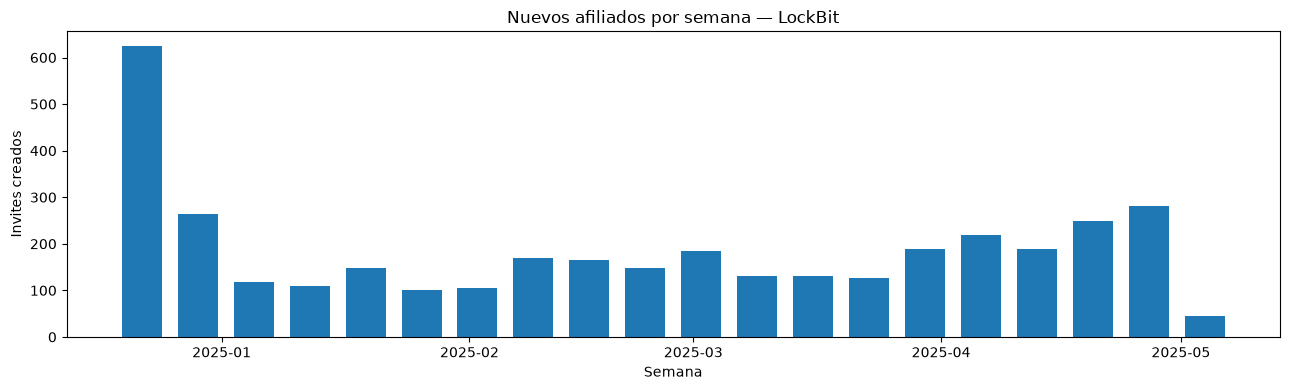

In [11]:
# Visualizamos la evolución temporal del reclutamiento de afiliados semana a semana.
# Un pico repentino puede indicar una campaña de expansión o un momento de alta actividad.

# Calculamos cuántos invites se crearon cada semana.
# Primero descartamos los que no tienen fecha, luego agrupamos por semana.
inv_weekly = invites.dropna(subset=['created_at']).set_index('created_at').resample('W').size()

# Creamos el gráfico de barras temporal
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(inv_weekly.index, inv_weekly.values, width=5)
ax.set_title('Nuevos afiliados por semana — LockBit')
ax.set_xlabel('Semana')
ax.set_ylabel('Invites creados')
plt.tight_layout()
plt.show()

## 5. Relaciones operador → víctima → build

Mapa de la estructura operacional: qué operadores controlan qué víctimas  
y qué variante de malware usaron.

In [12]:
# Construimos una tabla enriquecida que combina datos de víctimas, builds y operadores.
# Esto nos permite responder preguntas como:
# "¿Qué versión de LockBit usó el operador X contra sus víctimas?"

# .merge() combina dos tablas, como un JOIN en SQL.
# Paso 1: combinamos 'clients' con información de su 'build' (build_id vincula ambas tablas)
#   builds[['id','type','company_website','revenue']] → solo las columnas que nos interesan del build
#   .rename(columns={'id':'build_id'}) → renombramos 'id' a 'build_id' para hacer el merge correctamente
#   on='build_id' → la columna en común para unir las tablas
#   how='left' → LEFT JOIN: conservamos todas las víctimas, aunque no tengan build asociado
enriched = (clients
            .merge(builds[['id','type','company_website','revenue']].rename(columns={'id':'build_id'}),
                   on='build_id', how='left')
            # Paso 2: añadimos el nombre del operador usando su ID (advid en clients = id en users)
            .merge(users[['id','login']].rename(columns={'id':'advid','login':'operator'}),
                   on='advid', how='left'))

# Distribución de variantes de malware usadas contra las víctimas
print('Distribución de variante de malware usada por las víctimas:')
# .value_counts() cuenta las ocurrencias de cada versión
# .map(lambda t: f'{t} víctimas') añade "víctimas" al final de cada número para mayor claridad
print(enriched.type.value_counts().map(lambda t: f'{t} víctimas').to_string())
print()

# Ranking de operadores por número de víctimas (usando el nombre en lugar del ID numérico)
print('Operadores con más víctimas (top 10):')
# groupby('operator') agrupa por nombre de operador
# .size() cuenta cuántas víctimas tiene cada uno
# .sort_values(ascending=False) ordena de mayor a menor
print(enriched.groupby('operator').size().sort_values(ascending=False).head(10).to_string())

Distribución de variante de malware usada por las víctimas:
type
30    168 víctimas
25     31 víctimas
46     24 víctimas
50     21 víctimas
40      2 víctimas

Operadores con más víctimas (top 10):
operator
Christopher      44
jhon0722         42
PiotrBond        19
JamesCraig       17
Swan             17
Iofikdis         12
umarbishop47     10
Anon666           7
smelly            7
btcdrugdealer     6


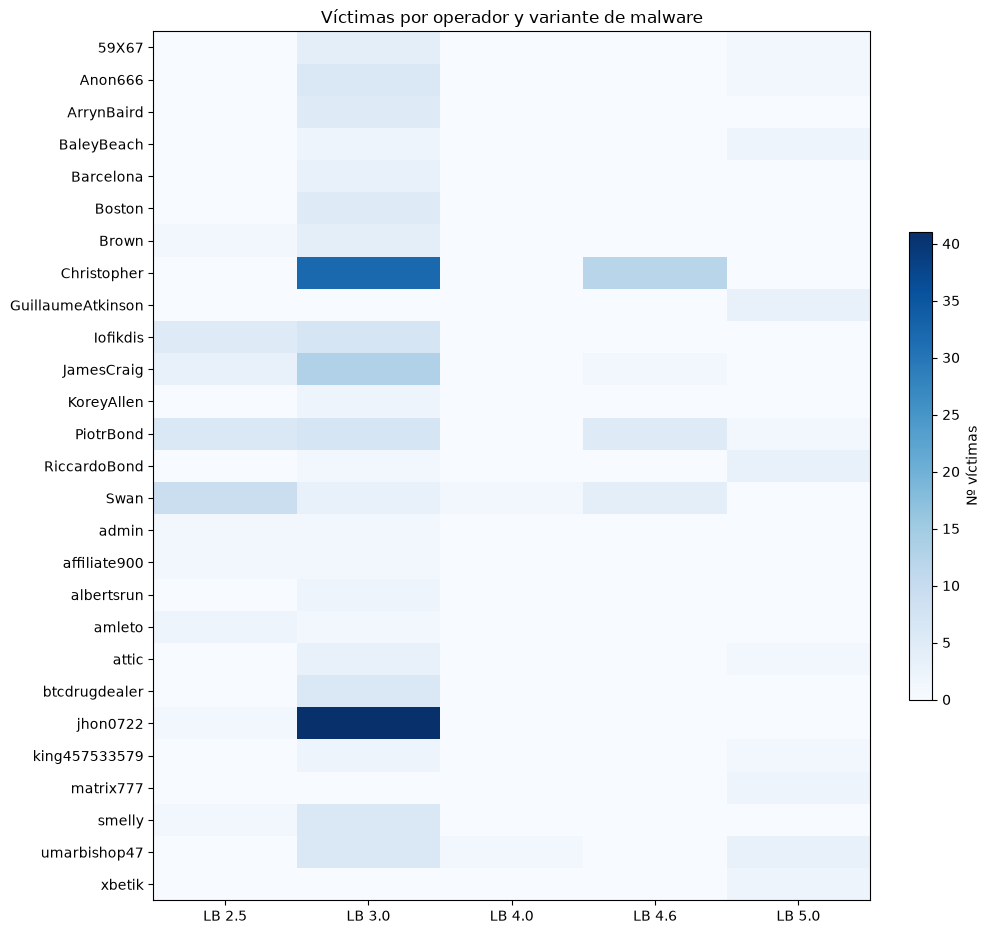

In [13]:
# Creamos un heatmap (mapa de calor) que muestra qué operadores usaron qué versiones de LockBit.
# Un heatmap usa colores para representar valores numéricos: más oscuro = más víctimas.
# Esto permite detectar patrones: ¿hay operadores especializados en una versión concreta?

# Construimos una "tabla pivote": filas = operadores, columnas = versión de LockBit, valores = nº víctimas.
# .groupby(['operator', 'type']).size() → cuenta las combinaciones (operador, versión)
# .unstack() → convierte el segundo nivel del índice ('type') en columnas
# fill_value=0 → rellena con 0 donde no hay datos (el operador no usó esa versión)
pivot = enriched.groupby(['operator', 'type']).size().unstack(fill_value=0)

# Filtramos para mostrar solo los operadores que tuvieron al menos 2 víctimas.
# Esto elimina los operadores con muy poca actividad que harían el gráfico demasiado largo.
# .sum(axis=1) suma todos los tipos por fila (total de víctimas por operador)
pivot = pivot[pivot.sum(axis=1) >= 2]

if len(pivot) > 0:
    # Ajustamos el alto de la figura según el número de operadores que hay.
    # max(4, len(pivot) * 0.35) asegura un mínimo de 4 pulgadas de alto,
    # pero si hay muchos operadores, la figura crece para que quepan todos.
    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.35)))

    # ax.imshow() dibuja la tabla como imagen donde cada celda tiene un color según su valor.
    # aspect='auto' ajusta el aspecto de las celdas automáticamente
    # cmap='Blues' usa una paleta de azules: más oscuro = más víctimas
    im = ax.imshow(pivot.values, aspect='auto', cmap='Blues')

    # Configuramos las etiquetas del eje X (columnas = versiones de LockBit)
    ax.set_xticks(range(len(pivot.columns)))
    # type_names.get(c, str(c)) traduce el código numérico al nombre, o lo deja como texto si no está
    ax.set_xticklabels([type_names.get(c, str(c)) for c in pivot.columns])

    # Configuramos las etiquetas del eje Y (filas = nombres de operadores)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index)

    # Añadimos una barra de colores lateral que explica la escala (qué oscuridad = cuántas víctimas)
    # fraction=0.03 controla el ancho de la barra de colores respecto al gráfico principal
    plt.colorbar(im, ax=ax, fraction=0.03, label='Nº víctimas')

    ax.set_title('Víctimas por operador y variante de malware')
    plt.tight_layout()
    plt.show()